Architecture:
- Level 0: Extra Trees + LSTM (base models)
- Level 1: Ridge Regression (meta-model learns to combine them)
- Feature selection: top features from FFT + time domain

In [2]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew
from numpy.fft import fft
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")
print("Libraries loaded!")

Libraries loaded!


# Step 1: Load Training Features (with FFT)

In [3]:
df = pd.read_csv("train_features_v2.csv")
df["RUL_norm"] = df["RUL"] / df["total_steps"]

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Bearings: {df['bearing'].unique()}")
print(f"Features available: {df.shape[1] - 4}")  # exclude RUL, bearing, time_step, total_steps

Loaded: 7534 rows, 33 columns
Bearings: ['Bearing1_1' 'Bearing1_2' 'Bearing2_1' 'Bearing2_2' 'Bearing3_1'
 'Bearing3_2']
Features available: 29


# Step 2: Feature Selection
Use Extra Trees importance to select top features from all 30
(12 time-domain + 18 FFT frequency-domain features).

In [4]:
all_features = [c for c in df.columns if c not in 
                ["RUL", "bearing", "time_step", "total_steps", "RUL_norm"]]

X_all = df[all_features].values
y_all = df["RUL_norm"].values

# Quick ET to get importances
et_selector = ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1)
et_selector.fit(X_all, y_all)

feat_imp = pd.Series(et_selector.feature_importances_, index=all_features)
feat_imp = feat_imp.sort_values(ascending=False)

print("Top 15 Feature Importances:")
print(feat_imp.head(15).to_string())

# Select top 8
top_features = feat_imp.head(8).index.tolist()
print(f"\nSelected top 8 features: {top_features}")

Top 15 Feature Importances:
energy_mid_x          0.107790
energy_high_x         0.093333
rms_x                 0.086483
fft_mean_x            0.073742
std_x                 0.072958
energy_mid_y          0.057680
energy_low_x          0.057454
fft_std_x             0.054750
spectral_entropy_x    0.049982
kurtosis_x            0.047838
peak_x                0.041752
spectral_entropy_y    0.039573
crest_x               0.030392
fft_peak_x            0.021229
fft_mean_y            0.018190

Selected top 8 features: ['energy_mid_x', 'energy_high_x', 'rms_x', 'fft_mean_x', 'std_x', 'energy_mid_y', 'energy_low_x', 'fft_std_x']


# Step 3: Prepare Features and Target

In [5]:
X      = df[top_features].values
y      = df["RUL_norm"].values
groups = df["bearing"].values

print(f"Features: {top_features}")
print(f"Samples:  {len(X)}")

Features: ['energy_mid_x', 'energy_high_x', 'rms_x', 'fft_mean_x', 'std_x', 'energy_mid_y', 'energy_low_x', 'fft_std_x']
Samples:  7534


# Step 4: Train/Validation Split by Bearing

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]

print(f"Train bearings: {set(groups[train_idx])}")
print(f"Val bearings:   {set(groups[val_idx])}")
print(f"Train samples:  {len(X_train)}")
print(f"Val samples:    {len(X_val)}")

Train bearings: {'Bearing2_1', 'Bearing3_2', 'Bearing2_2', 'Bearing3_1'}
Val bearings:   {'Bearing1_2', 'Bearing1_1'}
Train samples:  3860
Val samples:    3674


# Step 5: Train Base Model 1 — Extra Trees
Level 0 model. Uses selected features directly.
Provides uncertainty via tree variance.

In [7]:
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import xgboost as xgb

# 1. Extra Trees
et = ExtraTreesRegressor(
    n_estimators=300, max_depth=8,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
et.fit(X_train, y_train)
et_pred_val = et.predict(X_val)
et_r2   = r2_score(y_val, et_pred_val)
et_rmse = np.sqrt(mean_squared_error(y_val, et_pred_val))
et_mae  = mean_absolute_error(y_val, et_pred_val)
print(f"Extra Trees     → R²: {et_r2:.4f} | RMSE: {et_rmse:.4f} | MAE: {et_mae:.4f}")

# 2. Random Forest
rf = RandomForestRegressor(
    n_estimators=300, max_depth=8,
    min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred_val = rf.predict(X_val)
rf_r2   = r2_score(y_val, rf_pred_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred_val))
rf_mae  = mean_absolute_error(y_val, rf_pred_val)
print(f"Random Forest   → R²: {rf_r2:.4f} | RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f}")

# 3. XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_pred_val = xgb_model.predict(X_val)
xgb_r2   = r2_score(y_val, xgb_pred_val)
xgb_rmse = np.sqrt(mean_squared_error(y_val, xgb_pred_val))
xgb_mae  = mean_absolute_error(y_val, xgb_pred_val)
print(f"XGBoost         → R²: {xgb_r2:.4f} | RMSE: {xgb_rmse:.4f} | MAE: {xgb_mae:.4f}")

# Retrain all on full data
et_full  = ExtraTreesRegressor(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_full  = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1)
xgb_full = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)

et_full.fit(X, y)
rf_full.fit(X, y)
xgb_full.fit(X, y)
print("\nAll base models trained on full data!")

Extra Trees     → R²: 0.3686 | RMSE: 0.2294 | MAE: 0.1935
Random Forest   → R²: -1.9112 | RMSE: 0.4925 | MAE: 0.4068
XGBoost         → R²: -0.3659 | RMSE: 0.3374 | MAE: 0.2730

All base models trained on full data!


# Step 6: Prepare Sequences for LSTM
LSTM needs 3D input: (samples, timesteps, features)
Sequence length = 30 steps = last 5 minutes of vibration history.

In [8]:
SEQUENCE_LENGTH = 30

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[top_features] = scaler.fit_transform(df[top_features])

def create_sequences(data_df, feature_cols, target_col, seq_len):
    X_seq, y_seq, groups_seq, orig_idx = [], [], [], []
    for bearing in data_df["bearing"].unique():
        b_data = data_df[data_df["bearing"] == bearing].reset_index(drop=True)
        orig_indices = data_df[data_df["bearing"] == bearing].index.tolist()
        X_b = b_data[feature_cols].values
        y_b = b_data[target_col].values
        for i in range(seq_len, len(b_data)):
            X_seq.append(X_b[i-seq_len:i])
            y_seq.append(y_b[i])
            groups_seq.append(bearing)
            orig_idx.append(orig_indices[i])
    return np.array(X_seq), np.array(y_seq), np.array(groups_seq), np.array(orig_idx)

X_seq, y_seq, groups_seq, orig_idx = create_sequences(
    df_scaled, top_features, "RUL_norm", SEQUENCE_LENGTH
)

print(f"Sequence shape: {X_seq.shape}")
print(f"(samples, timesteps, features)")

Sequence shape: (7354, 30, 8)
(samples, timesteps, features)


# Step 7: Train/Val Split for LSTM

In [9]:
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=42)
train_idx2, val_idx2 = next(gss2.split(X_seq, y_seq, groups_seq))

X_train_seq, X_val_seq = X_seq[train_idx2], X_seq[val_idx2]
y_train_seq, y_val_seq = y_seq[train_idx2], y_seq[val_idx2]

print(f"Train sequences: {len(X_train_seq)}")
print(f"Val sequences:   {len(X_val_seq)}")
print(f"Train bearings:  {set(groups_seq[train_idx2])}")
print(f"Val bearings:    {set(groups_seq[val_idx2])}")

Train sequences: 3740
Val sequences:   3614
Train bearings:  {np.str_('Bearing2_1'), np.str_('Bearing3_2'), np.str_('Bearing2_2'), np.str_('Bearing3_1')}
Val bearings:    {np.str_('Bearing1_2'), np.str_('Bearing1_1')}


# Step 8: Train Base Model 2 — Bidirectional LSTM
Level 0 model. Learns temporal degradation patterns from sequences.
Architecture: BiLSTM → Dropout → LSTM → Dropout → Dense

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
n_features = X_train_seq.shape[2]

model_lstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(SEQUENCE_LENGTH, n_features)),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse", metrics=["mae"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5)

history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=100, batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

lstm_pred_val = model_lstm.predict(X_val_seq).flatten()
lstm_r2   = r2_score(y_val_seq, lstm_pred_val)
lstm_rmse = np.sqrt(mean_squared_error(y_val_seq, lstm_pred_val))
lstm_mae  = mean_absolute_error(y_val_seq, lstm_pred_val)

print(f"\nLSTM (Base Model 2)")
print(f"  R²:   {lstm_r2:.4f}")
print(f"  RMSE: {lstm_rmse:.4f}")
print(f"  MAE:  {lstm_mae:.4f}")

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0598 - mae: 0.2100 - val_loss: 0.0757 - val_mae: 0.2017 - learning_rate: 0.0010
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0435 - mae: 0.1692 - val_loss: 0.0546 - val_mae: 0.1667 - learning_rate: 0.0010
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0354 - mae: 0.1487 - val_loss: 0.0683 - val_mae: 0.1907 - learning_rate: 0.0010
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0311 - mae: 0.1363 - val_loss: 0.0762 - val_mae: 0.2181 - learning_rate: 0.0010
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0308 - mae: 0.1341 - val_loss: 0.1099 - val_mae: 0.2521 - learning_rate: 0.0010
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0286 - mae: 0.1279 - val_loss: 0.1063 - val_mae: 0.2461 - learning_rate: 0.0010
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0249 - mae: 0.1176 - val_loss: 0.1228 - val_mae: 0.2731 - learning_rate:

# Step 9: Build Stacking Meta-Dataset
Use out-of-fold predictions from both base models as input
to the meta-model. This prevents data leakage in stacking.
Each base model predicts on bearings it was NOT trained on.

In [11]:
gkf = GroupKFold(n_splits=3)

et_oof   = np.zeros(len(X))
rf_oof   = np.zeros(len(X))
xgb_oof  = np.zeros(len(X))
lstm_oof = np.zeros(len(X))

print("Building out-of-fold predictions for stacking...")

for fold, (tr_idx, oof_idx) in enumerate(gkf.split(X, y, groups)):
    print(f"\nFold {fold+1}: train={set(groups[tr_idx])} | oof={set(groups[oof_idx])}")
    
    # ET OOF
    et_oof_model = ExtraTreesRegressor(n_estimators=200, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1)
    et_oof_model.fit(X[tr_idx], y[tr_idx])
    et_oof[oof_idx] = et_oof_model.predict(X[oof_idx])
    
    # RF OOF
    rf_oof_model = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1)
    rf_oof_model.fit(X[tr_idx], y[tr_idx])
    rf_oof[oof_idx] = rf_oof_model.predict(X[oof_idx])
    
    # XGBoost OOF
    xgb_oof_model = xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=0)
    xgb_oof_model.fit(X[tr_idx], y[tr_idx])
    xgb_oof[oof_idx] = xgb_oof_model.predict(X[oof_idx])
    
    # LSTM OOF
    X_scaled_all = scaler.transform(X)
    X_oof_seqs, y_oof_seqs, oof_seq_orig = [], [], []
    for bearing in set(groups[oof_idx]):
        mask = groups == bearing
        b_idx = np.where(mask)[0]
        X_b = X_scaled_all[mask]
        for i in range(SEQUENCE_LENGTH, len(X_b)):
            X_oof_seqs.append(X_b[i-SEQUENCE_LENGTH:i])
            y_oof_seqs.append(y[b_idx[i]])
            oof_seq_orig.append(b_idx[i])
    
    if X_oof_seqs:
        X_oof_seqs = np.array(X_oof_seqs)
        lstm_oof_preds = model_lstm.predict(X_oof_seqs, verbose=0, batch_size=256).flatten()
        for i, orig_i in enumerate(oof_seq_orig):
            lstm_oof[orig_i] = lstm_oof_preds[i]

# Build meta-dataset with 4 base model predictions
meta_X = np.column_stack([et_oof, rf_oof, xgb_oof, lstm_oof])
meta_y = y

print(f"\nMeta dataset shape: {meta_X.shape}")
print(f"(ET, RF, XGBoost, LSTM predictions) → RUL_norm")

Building out-of-fold predictions for stacking...

Fold 1: train={'Bearing2_2', 'Bearing3_1', 'Bearing3_2', 'Bearing2_1', 'Bearing1_2'} | oof={'Bearing1_1'}

Fold 2: train={'Bearing2_1', 'Bearing1_2', 'Bearing1_1', 'Bearing3_1'} | oof={'Bearing2_2', 'Bearing3_2'}

Fold 3: train={'Bearing2_2', 'Bearing1_1', 'Bearing3_2'} | oof={'Bearing2_1', 'Bearing1_2', 'Bearing3_1'}

Meta dataset shape: (7534, 4)
(ET, RF, XGBoost, LSTM predictions) → RUL_norm


# Step 10: Train Meta-Model (Ridge Regression)
Ridge Regression learns the optimal weights to combine
Extra Trees and LSTM predictions.
It answers: "When should I trust ET more vs LSTM more?"

In [12]:
gss3 = GroupShuffleSplit(n_splits=1, test_size=0.33, random_state=42)
m_train_idx, m_val_idx = next(gss3.split(meta_X, meta_y, groups))

meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_X[m_train_idx], meta_y[m_train_idx])

stack_pred_val = meta_model.predict(meta_X[m_val_idx])
stack_r2   = r2_score(meta_y[m_val_idx], stack_pred_val)
stack_rmse = np.sqrt(mean_squared_error(meta_y[m_val_idx], stack_pred_val))
stack_mae  = mean_absolute_error(meta_y[m_val_idx], stack_pred_val)

print(f"Meta-model weights:")
print(f"  Extra Trees weight:  {meta_model.coef_[0]:.4f}")
print(f"  Random Forest weight:{meta_model.coef_[1]:.4f}")
print(f"  XGBoost weight:      {meta_model.coef_[2]:.4f}")
print(f"  LSTM weight:         {meta_model.coef_[3]:.4f}")
print(f"  Intercept:           {meta_model.intercept_:.4f}")

print(f"\nStacking Ensemble (4 models) Results:")
print(f"  R²:   {stack_r2:.4f}")
print(f"  RMSE: {stack_rmse:.4f}")
print(f"  MAE:  {stack_mae:.4f}")

Meta-model weights:
  Extra Trees weight:  0.9350
  Random Forest weight:-0.0957
  XGBoost weight:      -0.3706
  LSTM weight:         0.4539
  Intercept:           0.0252

Stacking Ensemble (4 models) Results:
  R²:   0.4544
  RMSE: 0.2132
  MAE:  0.1713


# Step 11: Full Model Comparison

In [13]:
print("=" * 60)
print(f"{'Model':<30} {'R²':>8} {'RMSE':>8} {'MAE':>8}")
print("=" * 60)
print(f"{'Extra Trees (base)':<30} {et_r2:>8.4f} {et_rmse:>8.4f} {et_mae:>8.4f}")
print(f"{'Random Forest (base)':<30} {rf_r2:>8.4f} {rf_rmse:>8.4f} {rf_mae:>8.4f}")
print(f"{'XGBoost (base)':<30} {xgb_r2:>8.4f} {xgb_rmse:>8.4f} {xgb_mae:>8.4f}")
print(f"{'LSTM Bidirectional (base)':<30} {lstm_r2:>8.4f} {lstm_rmse:>8.4f} {lstm_mae:>8.4f}")
print(f"{'Stacking Ensemble (meta)':<30} {stack_r2:>8.4f} {stack_rmse:>8.4f} {stack_mae:>8.4f}")
print("=" * 60)

best_r2 = max(et_r2, rf_r2, xgb_r2, lstm_r2, stack_r2)
if best_r2 == stack_r2:
    best_name = "Stacking Ensemble"
elif best_r2 == lstm_r2:
    best_name = "LSTM"
elif best_r2 == xgb_r2:
    best_name = "XGBoost"
elif best_r2 == rf_r2:
    best_name = "Random Forest"
else:
    best_name = "Extra Trees"

print(f"\n✅ Best model: {best_name} (R²={best_r2:.4f})")

Model                                R²     RMSE      MAE
Extra Trees (base)               0.3686   0.2294   0.1935
Random Forest (base)            -1.9112   0.4925   0.4068
XGBoost (base)                  -0.3659   0.3374   0.2730
LSTM Bidirectional (base)        0.3234   0.2336   0.1667
Stacking Ensemble (meta)         0.4544   0.2132   0.1713

✅ Best model: Stacking Ensemble (R²=0.4544)


# Step 12: Extract Features from Test Bearings

In [14]:
def extract_features_full(filepath):
    df_raw = pd.read_csv(filepath, header=None)
    ax = df_raw[4].values
    ay = df_raw[5].values if 5 in df_raw.columns else ax
    features = {}
    for name, sig in [("x", ax), ("y", ay)]:
        features[f"rms_{name}"]      = np.sqrt(np.mean(sig**2))
        features[f"peak_{name}"]     = np.max(np.abs(sig))
        features[f"kurtosis_{name}"] = kurtosis(sig)
        features[f"skew_{name}"]     = skew(sig)
        features[f"std_{name}"]      = np.std(sig)
        features[f"crest_{name}"]    = np.max(np.abs(sig)) / (np.sqrt(np.mean(sig**2)) + 1e-10)
        fft_vals = np.abs(fft(sig))[:len(sig)//2]
        freqs    = np.linspace(0, 12800, len(fft_vals))
        features[f"fft_mean_{name}"]     = np.mean(fft_vals)
        features[f"fft_std_{name}"]      = np.std(fft_vals)
        features[f"fft_peak_{name}"]     = np.max(fft_vals)
        features[f"fft_kurtosis_{name}"] = kurtosis(fft_vals)
        features[f"spectral_entropy_{name}"] = -np.sum(
            (fft_vals/np.sum(fft_vals)) * np.log(fft_vals/np.sum(fft_vals) + 1e-10)
        )
        features[f"energy_low_{name}"]  = np.sum(fft_vals[freqs < 1000]**2)
        features[f"energy_mid_{name}"]  = np.sum(fft_vals[(freqs >= 1000) & (freqs < 5000)]**2)
        features[f"energy_high_{name}"] = np.sum(fft_vals[freqs >= 5000]**2)
    return features

test_path = "Test_set"
all_test  = []
for bearing in sorted(os.listdir(test_path)):
    path  = os.path.join(test_path, bearing)
    files = sorted([f for f in os.listdir(path) if f.startswith("acc_")])
    records = []
    for i, f in enumerate(files):
        feats = extract_features_full(os.path.join(path, f))
        feats["time_step"]   = i
        feats["total_steps"] = len(files)
        feats["bearing"]     = bearing
        records.append(feats)
    all_test.append(pd.DataFrame(records))
    print(f"  {bearing}: {len(files)} files")

test_df = pd.concat(all_test, ignore_index=True)
print(f"\nTotal test rows: {test_df.shape[0]}")

  Bearing1_3: 1802 files
  Bearing1_4: 1139 files
  Bearing1_5: 2302 files
  Bearing1_6: 2302 files
  Bearing1_7: 1502 files
  Bearing2_3: 1202 files
  Bearing2_4: 612 files
  Bearing2_5: 2002 files
  Bearing2_6: 572 files
  Bearing2_7: 172 files
  Bearing3_3: 352 files

Total test rows: 13959


# Step 13: Predict Using Stacking Ensemble
1. Extra Trees predicts from features
2. LSTM predicts from sequences
3. Meta-model combines both predictions
4. Uncertainty from ET tree variance + LSTM rolling std

In [15]:
def classify_health(rul_norm):
    if rul_norm <= 0.20:
        return "Imminent failure"
    elif rul_norm <= 0.50:
        return "Wear detectable"
    else:
        return "Non-critical"

X_test        = test_df[top_features].values
X_test_scaled = scaler.transform(X_test)

# ET predictions + uncertainty
preds_trees  = np.array([tree.predict(X_test) for tree in et_full.estimators_])
et_pred_test = np.clip(preds_trees.mean(axis=0), 0, 1)
et_std_test  = preds_trees.std(axis=0)

# RF predictions + uncertainty
preds_trees_rf = np.array([tree.predict(X_test) for tree in rf_full.estimators_])
rf_pred_test   = np.clip(preds_trees_rf.mean(axis=0), 0, 1)
rf_std_test    = preds_trees_rf.std(axis=0)

# XGBoost predictions
xgb_pred_test = np.clip(xgb_full.predict(X_test), 0, 1)

# LSTM batch predictions
lstm_pred_test = np.zeros(len(test_df))
lstm_std_test  = np.zeros(len(test_df))

for bearing in test_df["bearing"].unique():
    mask = test_df["bearing"] == bearing
    idx  = np.where(mask)[0]
    X_b  = X_test_scaled[mask]
    if len(X_b) <= SEQUENCE_LENGTH:
        lstm_pred_test[idx] = et_pred_test[idx]
        continue
    n_seqs = len(X_b) - SEQUENCE_LENGTH
    batch  = np.array([X_b[i:i+SEQUENCE_LENGTH] for i in range(n_seqs)])
    preds  = model_lstm.predict(batch, verbose=0, batch_size=256).flatten()
    full_preds = np.concatenate([[preds[0]] * SEQUENCE_LENGTH, preds])
    full_preds = np.clip(full_preds[:len(idx)], 0, 1)
    lstm_pred_test[idx] = full_preds
    lstm_std_test[idx]  = pd.Series(full_preds).rolling(10, min_periods=1).std().fillna(0).values

# Stack all 4 through meta-model
meta_test_X     = np.column_stack([et_pred_test, rf_pred_test, xgb_pred_test, lstm_pred_test])
stack_pred_test = np.clip(meta_model.predict(meta_test_X), 0, 1)

# Combined uncertainty
combined_std = (et_std_test + rf_std_test + lstm_std_test) / 3

# Smooth
smoothed_pred, smoothed_std = [], []
for bearing in test_df["bearing"].unique():
    mask  = test_df["bearing"] == bearing
    preds = pd.Series(stack_pred_test[mask]).rolling(20, min_periods=1).mean().values
    stds  = pd.Series(combined_std[mask]).rolling(20, min_periods=1).mean().values
    smoothed_pred.extend(preds)
    smoothed_std.extend(stds)

bearing_total = test_df.groupby("bearing")["total_steps"].first()
test_df["pred_norm"]       = np.clip(smoothed_pred, 0, 1)
test_df["std_norm"]        = smoothed_std
test_df["Predicted_RUL_s"] = test_df["pred_norm"] * test_df["bearing"].map(bearing_total) * 10
test_df["Uncertainty_s"]   = test_df["std_norm"]  * test_df["bearing"].map(bearing_total) * 10
test_df["Lower_RUL_s"]     = np.maximum(test_df["Predicted_RUL_s"] - test_df["Uncertainty_s"], 0)
test_df["Upper_RUL_s"]     = test_df["Predicted_RUL_s"] + test_df["Uncertainty_s"]
test_df["Health_State"]    = test_df["pred_norm"].apply(classify_health)

print("Predictions done!")

Predictions done!


# Step 14: Final Results

In [16]:
actual_rul = {
    "Bearing1_3": 5730, "Bearing1_4": 339,  "Bearing1_5": 1610,
    "Bearing1_6": 1460, "Bearing1_7": 7570, "Bearing2_3": 7530,
    "Bearing2_4": 1390, "Bearing2_5": 3090, "Bearing2_6": 1290,
    "Bearing2_7": 580,  "Bearing3_3": 820
}

latest = test_df.sort_values("time_step").groupby("bearing").last().reset_index()

print(f"Final Model: Stacking Ensemble (ET + RF + XGBoost + LSTM)\n")
print(f"{'Bearing':<12} {'Predicted(s)':>13} {'Actual(s)':>10} {'Error%':>8} {'Uncertainty':>13} {'Health'}")
print("-" * 85)

errors = []
for _, row in latest.iterrows():
    b      = row["bearing"]
    pred_s = row["Predicted_RUL_s"]
    act_s  = actual_rul[b]
    unc_s  = row["Uncertainty_s"]
    health = row["Health_State"]
    err    = abs(pred_s - act_s) / act_s * 100
    errors.append(err)
    print(f"{b:<12} {pred_s:>13.0f} {act_s:>10} {err:>7.1f}% {unc_s:>12.0f}s  {health}")

print("-" * 85)
print(f"Average Error: {np.mean(errors):.1f}%")
print(f"Best  Error:   {np.min(errors):.1f}%")
print(f"Worst Error:   {np.max(errors):.1f}%")

Final Model: Stacking Ensemble (ET + RF + XGBoost + LSTM)

Bearing       Predicted(s)  Actual(s)   Error%   Uncertainty Health
-------------------------------------------------------------------------------------
Bearing1_3            4171       5730    27.2%         1290s  Wear detectable
Bearing1_4             532        339    56.9%           26s  Imminent failure
Bearing1_5            9163       1610   469.2%         2069s  Wear detectable
Bearing1_6           15325       1460   949.7%         1380s  Non-critical
Bearing1_7            8520       7570    12.5%         1820s  Non-critical
Bearing2_3            4435       7530    41.1%         1084s  Wear detectable
Bearing2_4            2983       1390   114.6%          291s  Wear detectable
Bearing2_5            9449       3090   205.8%         1973s  Wear detectable
Bearing2_6            1425       1290    10.5%          558s  Wear detectable
Bearing2_7            1148        580    97.9%          110s  Non-critical
Bearing3_3     

In [17]:
# Save cell

joblib.dump(et_full, "et_model_v4.pkl")
joblib.dump(rf_full, "rf_model_v4.pkl")
joblib.dump(xgb_full, "xgb_model_v4.pkl")
joblib.dump(meta_model, "meta_model_v4.pkl")
joblib.dump(scaler, "scaler_v4.pkl")
joblib.dump(top_features, "top_features_v4.pkl")
model_lstm.save("lstm_model_v4.keras")
test_df.to_csv("Finalbest_test_predictions_timeseries_v4.csv", index=False)
latest.to_csv("Finalbest_test_predictions_final_v4.csv", index=False)
print("All saved!")

All saved!


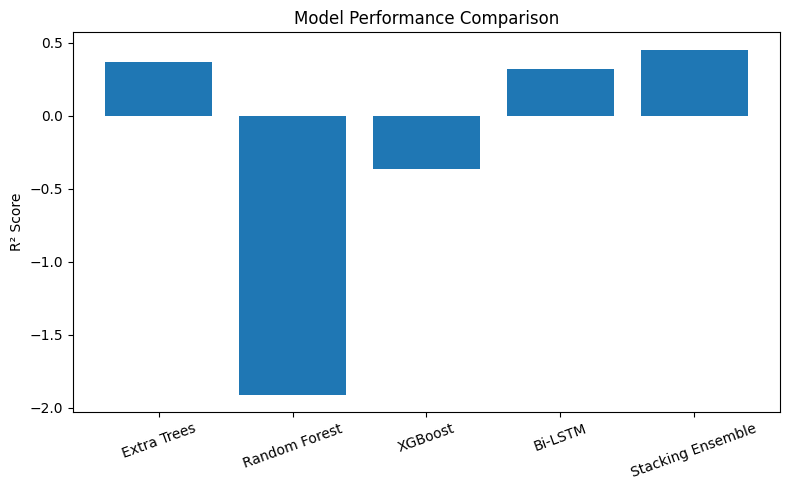

In [20]:
import matplotlib.pyplot as plt
metrics_df = pd.DataFrame({
    "Model": [
        "Extra Trees",
        "Random Forest",
        "XGBoost",
        "Bi-LSTM",
        "Stacking Ensemble"
    ],
    "R2": [et_r2, rf_r2, xgb_r2, lstm_r2, stack_r2]
})

plt.figure(figsize=(8,5))
plt.bar(metrics_df["Model"], metrics_df["R2"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("model_comparison_r2.png")
plt.show()

In [18]:
metrics_df = pd.DataFrame({
    "Model": ["Stacking Ensemble (ET + RF + XGBoost + LSTM)"],
    "R2": [stack_r2],
    "RMSE": [stack_rmse],
    "MAE": [stack_mae]
})

metrics_df.to_csv("model_metrics.csv", index=False)

print(metrics_df)

                                          Model      R2      RMSE       MAE
0  Stacking Ensemble (ET + RF + XGBoost + LSTM)  0.4544  0.213229  0.171293
